In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

def export_plot(filename):
    """
    Tự động tối ưu layout, lưu ảnh vào thư mục 'plots' và hiển thị biểu đồ.
    """
    output_dir = 'images'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Tự động căn chỉnh để không bị mất nhãn (label) khi lưu
    plt.tight_layout()

    # Lưu file
    path = os.path.join(output_dir, f"{filename}.png")
    plt.savefig(path, dpi=300) # dpi=300 để ảnh sắc nét khi chèn vào báo cáo
    print(f"✅ Đã lưu: {path}")

    # Hiển thị
    plt.show()

In [ ]:
# Thay đường dẫn trên máy
TRAIN_DIR = "/content/train.csv"
TEST_DIR  = "/content/test.csv"

df_train = pd.read_csv(TRAIN_DIR)
df_test  = pd.read_csv(TEST_DIR)

print("Train shape:", df_train.shape)
print("Test  shape:", df_test.shape)

Train shape: (140700, 20)
Test  shape: (93800, 19)


# Tổng quan Train Set

In [ ]:
display(df_train)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1,2.0,No,0
1,1,Vivan,Male,26,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7,3.0,No,1
2,2,Yuvraj,Male,33,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
3,3,Yuvraj,Male,22,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10,1.0,Yes,1
4,4,Rhea,Female,30,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,140695,Vidya,Female,18,Ahmedabad,Working Professional,NaN,NaN,5.0,NaN,NaN,4.0,5-6 hours,Unhealthy,Class 12,No,2,4.0,Yes,1
140696,140696,Lata,Female,41,Hyderabad,Working Professional,Content Writer,NaN,5.0,NaN,NaN,4.0,7-8 hours,Moderate,B.Tech,Yes,6,5.0,Yes,0
140697,140697,Aanchal,Female,24,Kolkata,Working Professional,Marketing Manager,NaN,3.0,NaN,NaN,1.0,More than 8 hours,Moderate,B.Com,No,4,4.0,No,0
140698,140698,Prachi,Female,49,Srinagar,Working Professional,Plumber,NaN,5.0,NaN,NaN,2.0,5-6 hours,Moderate,ME,Yes,10,1.0,No,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  int64  
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

# Tổng quan Test Set

In [ ]:
display(df_test)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,140702,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,140703,Nalini,Female,23.0,Rajkot,Student,NaN,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,140704,Shaurya,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93795,234495,Zoya,Female,49.0,Jaipur,Working Professional,Pilot,NaN,3.0,NaN,NaN,5.0,Less than 5 hours,Moderate,BSc,Yes,2.0,2.0,Yes
93796,234496,Shlok,Male,29.0,Ahmedabad,Working Professional,Pilot,NaN,5.0,NaN,NaN,1.0,7-8 hours,Moderate,BE,Yes,11.0,3.0,Yes
93797,234497,Rishi,Male,24.0,Visakhapatnam,Student,NaN,1.0,NaN,7.51,4.0,NaN,7-8 hours,Moderate,B.Tech,No,7.0,1.0,No
93798,234498,Eshita,Female,23.0,Kalyan,Working Professional,Marketing Manager,NaN,4.0,NaN,NaN,2.0,5-6 hours,Healthy,BA,Yes,7.0,5.0,Yes


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93800 entries, 0 to 93799
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     93800 non-null  int64  
 1   Name                                   93800 non-null  object 
 2   Gender                                 93800 non-null  object 
 3   Age                                    93800 non-null  float64
 4   City                                   93800 non-null  object 
 5   Working Professional or Student        93800 non-null  object 
 6   Profession                             69168 non-null  object 
 7   Academic Pressure                      18767 non-null  float64
 8   Work Pressure                          75022 non-null  float64
 9   CGPA                                   18766 non-null  float64
 10  Study Satisfaction                     18767 non-null  float64
 11  Jo

## Hàm phân tích chung

In [ ]:
def analyze_depression(df, dataset_name):
    """Chạy toàn bộ phân tích Depression cho một dataframe."""
    prefix = dataset_name.lower().replace(" ", "_")

    print(f"\n{'='*60}")
    print(f"  PHÂN TÍCH: {dataset_name}")
    print(f"{'='*60}")

    # ── 0. Tổng quan ─────────────────────────────────────────────
    print(f"\nShape: {df.shape[0]:,} hàng × {df.shape[1]} cột")

    # Kiểm tra có cột Depression không (test set có thể không có)
    has_target = 'Depression' in df.columns

    # ── 1. Phân phối biến mục tiêu ───────────────────────────────
    if has_target:
        depression_counts = df['Depression'].value_counts().sort_index()
        depression_pct    = df['Depression'].value_counts(normalize=True).sort_index() * 100

        summary = pd.DataFrame({
            'Số lượng': depression_counts,
            'Tỷ lệ (%)': depression_pct.round(2)
        })
        summary.index = ['Không trầm cảm (0)', 'Trầm cảm (1)']
        print("\n--- Phân phối biến mục tiêu Depression ---")
        print(summary.to_string())

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'[{dataset_name}] Phân phối biến mục tiêu - Depression',
                     fontsize=13, fontweight='bold')

        labels = ['Không trầm cảm', 'Trầm cảm']
        colors = ['#4CAF50', '#F44336']
        cnts   = [depression_counts[0], depression_counts[1]]

        bars = axes[0].bar(labels, cnts, color=colors, edgecolor='white', linewidth=1.5)
        axes[0].set_title('Số lượng theo nhóm', fontsize=11)
        axes[0].set_ylabel('Số lượng')
        for bar, cnt in zip(bars, cnts):
            axes[0].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + max(cnts)*0.01,
                         f'{cnt:,}', ha='center', va='bottom',
                         fontsize=11, fontweight='bold')
        axes[0].set_ylim(0, max(cnts) * 1.14)

        pcts = [depression_pct[0], depression_pct[1]]
        wedges, texts, autotexts = axes[1].pie(
            pcts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for at in autotexts:
            at.set_fontsize(12); at.set_fontweight('bold')
        axes[1].set_title('Tỷ lệ phần trăm', fontsize=11)

        plt.tight_layout()
        plt.show()
    else:
        print("\n(Tập test không có cột Depression — bỏ qua phân tích phân phối mục tiêu)")
    export_plot(f"{prefix}_distribution")

    # ── 2. Tỷ lệ trầm cảm theo Áp lực ───────────────────────────
    df = df.copy()
    df['Pressure'] = df['Work Pressure'].combine_first(df['Academic Pressure'])

    pressure_depression = (
        df.dropna(subset=['Pressure'])
        .groupby('Pressure')['Depression']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'Depression Rate', 'count': 'Count'})
    ) if has_target else (
        df.dropna(subset=['Pressure'])
        .groupby('Pressure').size()
        .reset_index(name='Count')
    )

    if has_target:
        pressure_depression['Depression Rate (%)'] = (pressure_depression['Depression Rate'] * 100).round(2)
        pressure_depression['Pressure'] = pressure_depression['Pressure'].astype(int)

        print("\n--- Tỷ lệ trầm cảm theo Áp lực công việc/học tập ---")
        print(pressure_depression[['Pressure','Count','Depression Rate (%)']].to_string(index=False))

        fig, ax = plt.subplots(figsize=(10, 5))
        palette = sns.color_palette("RdYlGn_r", len(pressure_depression))
        bars = ax.bar(pressure_depression['Pressure'].astype(str),
                      pressure_depression['Depression Rate (%)'],
                      color=palette, edgecolor='white', linewidth=1.5)
        for bar, (_, row) in zip(bars, pressure_depression.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f"{row['Depression Rate (%)']:.1f}%\n(n={row['Count']:,})",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_title(f'[{dataset_name}] Tỷ lệ trầm cảm theo Áp lực công việc/học tập',
                     fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel('Mức áp lực (1 = Thấp nhất, 5 = Cao nhất)', fontsize=11)
        ax.set_ylabel('Tỷ lệ trầm cảm (%)', fontsize=11)
        ax.set_ylim(0, pressure_depression['Depression Rate (%)'].max() * 1.18)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.grid(axis='y', alpha=0.3); sns.despine()
        plt.tight_layout(); plt.show()
    else:
        pressure_depression['Pressure'] = pressure_depression['Pressure'].astype(int)
        print("\n--- Phân phối mức Áp lực (tập test — không có nhãn) ---")
        print(pressure_depression.to_string(index=False))

        fig, ax = plt.subplots(figsize=(10, 5))
        palette = sns.color_palette("Blues_d", len(pressure_depression))
        bars = ax.bar(pressure_depression['Pressure'].astype(str),
                      pressure_depression['Count'],
                      color=palette, edgecolor='white', linewidth=1.5)
        for bar, (_, row) in zip(bars, pressure_depression.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(pressure_depression['Count'])*0.01,
                    f"{row['Count']:,}", ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
        ax.set_title(f'[{dataset_name}] Phân phối mức Áp lực công việc/học tập',
                     fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel('Mức áp lực (1 = Thấp nhất, 5 = Cao nhất)', fontsize=11)
        ax.set_ylabel('Số lượng', fontsize=11)
        ax.grid(axis='y', alpha=0.3); sns.despine()
        plt.tight_layout(); plt.show()
    export_plot(f"{prefix}_pressure")

    # ── 3. Tỷ lệ trầm cảm theo Thời gian ngủ ────────────────────
    sleep_order  = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
    sleep_labels = ['< 5 giờ', '5-6 giờ', '7-8 giờ', '> 8 giờ']
    colors_sleep = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']

    if has_target:
        sleep_stats = (
            df[df['Sleep Duration'].isin(sleep_order)]
            .groupby('Sleep Duration')['Depression']
            .agg(['mean', 'count'])
            .reindex(sleep_order)
            .reset_index()
            .rename(columns={'mean': 'Depression Rate', 'count': 'Count'})
        )
        sleep_stats['Depression Rate (%)'] = (sleep_stats['Depression Rate'] * 100).round(2)
        sleep_stats['Sleep Label'] = sleep_labels

        print("\n--- Tỷ lệ trầm cảm theo Thời gian ngủ ---")
        print(sleep_stats[['Sleep Duration','Count','Depression Rate (%)']].to_string(index=False))

        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(sleep_stats['Sleep Label'], sleep_stats['Depression Rate (%)'],
                      color=colors_sleep, edgecolor='white', linewidth=1.5, width=0.55)
        for bar, (_, row) in zip(bars, sleep_stats.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.4,
                    f"{row['Depression Rate (%)']:.1f}%\n(n={row['Count']:,})",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.set_title(f'[{dataset_name}] Tỷ lệ trầm cảm theo Thời gian ngủ',
                     fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel('Thời gian ngủ mỗi đêm', fontsize=11)
        ax.set_ylabel('Tỷ lệ trầm cảm (%)', fontsize=11)
        ax.set_ylim(0, sleep_stats['Depression Rate (%)'].max() * 1.18)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.grid(axis='y', alpha=0.3); sns.despine()
        plt.tight_layout(); plt.show()
    else:
        sleep_counts = (
            df[df['Sleep Duration'].isin(sleep_order)]
            .groupby('Sleep Duration').size()
            .reindex(sleep_order)
            .reset_index(name='Count')
        )
        sleep_counts['Sleep Label'] = sleep_labels

        print("\n--- Phân phối Thời gian ngủ (tập test — không có nhãn) ---")
        print(sleep_counts[['Sleep Duration','Count']].to_string(index=False))

        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(sleep_counts['Sleep Label'], sleep_counts['Count'],
                      color=colors_sleep, edgecolor='white', linewidth=1.5, width=0.55)
        for bar, (_, row) in zip(bars, sleep_counts.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(sleep_counts['Count'])*0.01,
                    f"{row['Count']:,}", ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
        ax.set_title(f'[{dataset_name}] Phân phối Thời gian ngủ',
                     fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel('Thời gian ngủ mỗi đêm', fontsize=11)
        ax.set_ylabel('Số lượng', fontsize=11)
        ax.grid(axis='y', alpha=0.3); sns.despine()
        plt.tight_layout(); plt.show()
        export_plot(f"{prefix}_sleep")

## Phân tích Train Set


  PHÂN TÍCH: Train Set

Shape: 140,700 hàng × 20 cột

--- Phân phối biến mục tiêu Depression ---
                    Số lượng  Tỷ lệ (%)
Không trầm cảm (0)    115133      81.83
Trầm cảm (1)           25567      18.17


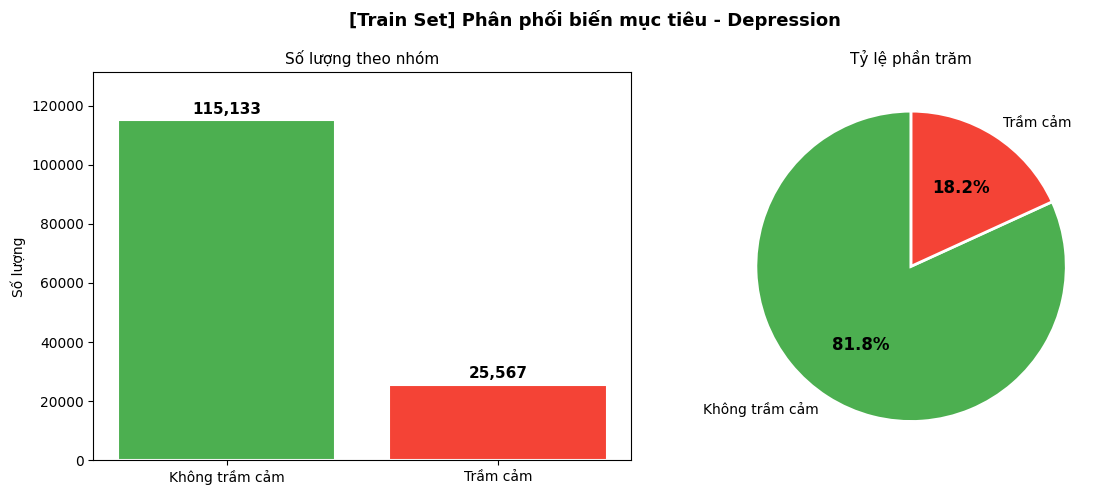

✅ Đã lưu: images/train_set_distribution.png


<Figure size 640x480 with 0 Axes>


--- Tỷ lệ trầm cảm theo Áp lực công việc/học tập ---
 Pressure  Count  Depression Rate (%)
        1  26363                 5.37
        2  28552                 8.24
        3  29362                19.35
        4  27670                22.72
        5  28732                34.18


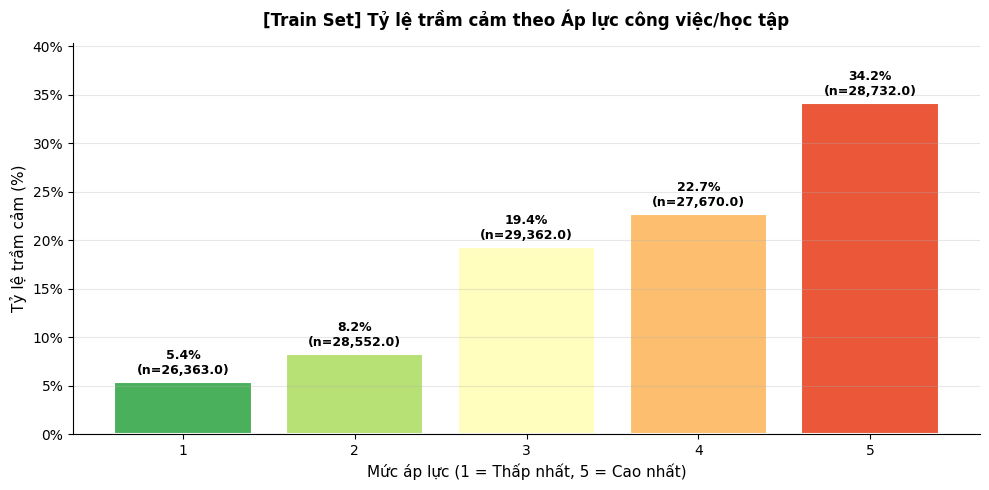

✅ Đã lưu: images/train_set_pressure.png


<Figure size 640x480 with 0 Axes>


--- Tỷ lệ trầm cảm theo Thời gian ngủ ---
   Sleep Duration  Count  Depression Rate (%)
Less than 5 hours  38784                23.47
        5-6 hours  32142                16.56
        7-8 hours  36969                17.83
More than 8 hours  32726                13.87


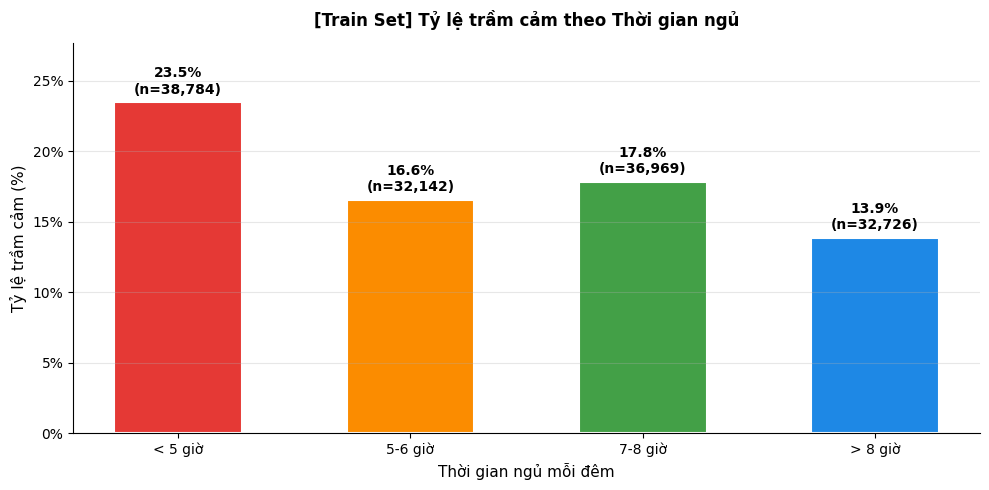

In [ ]:
analyze_depression(df_train, "Train Set")

## Phân tích Test Set


  PHÂN TÍCH: Test Set

Shape: 93,800 hàng × 19 cột

(Tập test không có cột Depression — bỏ qua phân tích phân phối mục tiêu)
✅ Đã lưu: images/test_set_distribution.png


<Figure size 640x480 with 0 Axes>


--- Phân phối mức Áp lực (tập test — không có nhãn) ---
 Pressure  Count
        1  17282
        2  18968
        3  19579
        4  18525
        5  19434


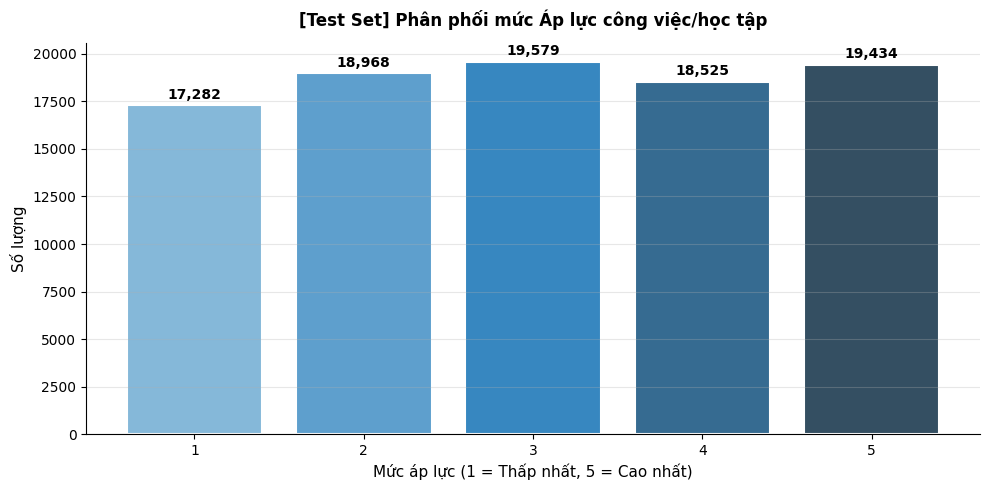

✅ Đã lưu: images/test_set_pressure.png


<Figure size 640x480 with 0 Axes>


--- Phân phối Thời gian ngủ (tập test — không có nhãn) ---
   Sleep Duration  Count
Less than 5 hours  25661
        5-6 hours  21404
        7-8 hours  24491
More than 8 hours  22190


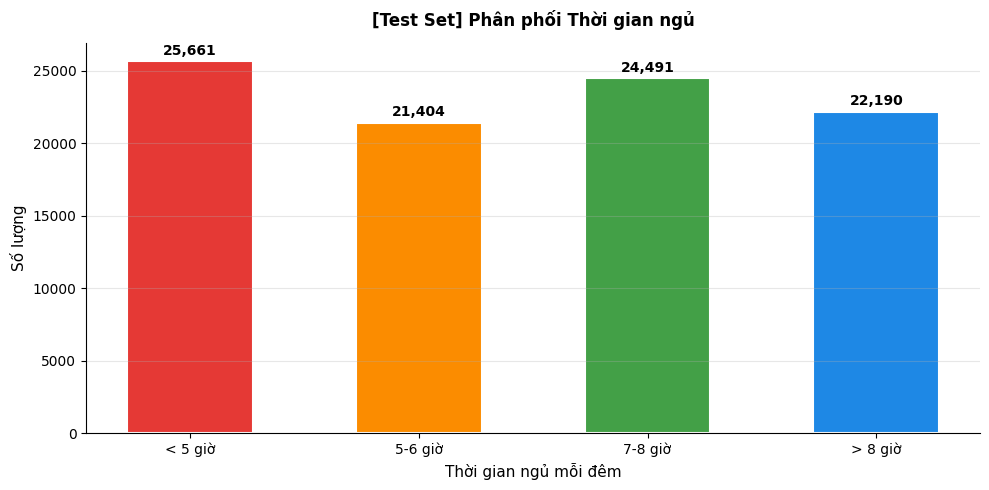

✅ Đã lưu: images/test_set_sleep.png


<Figure size 640x480 with 0 Axes>

In [ ]:
analyze_depression(df_test, "Test Set")

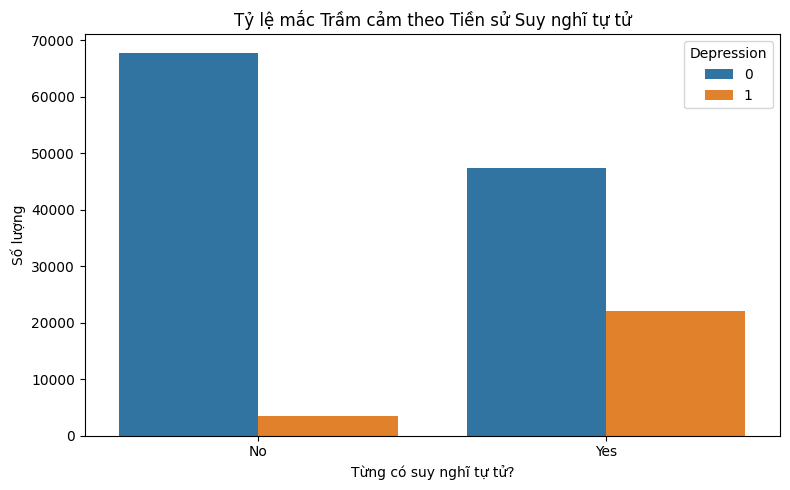

✅ Đã lưu: images/suicidal_thoughts_analysis.png


<Figure size 640x480 with 0 Axes>

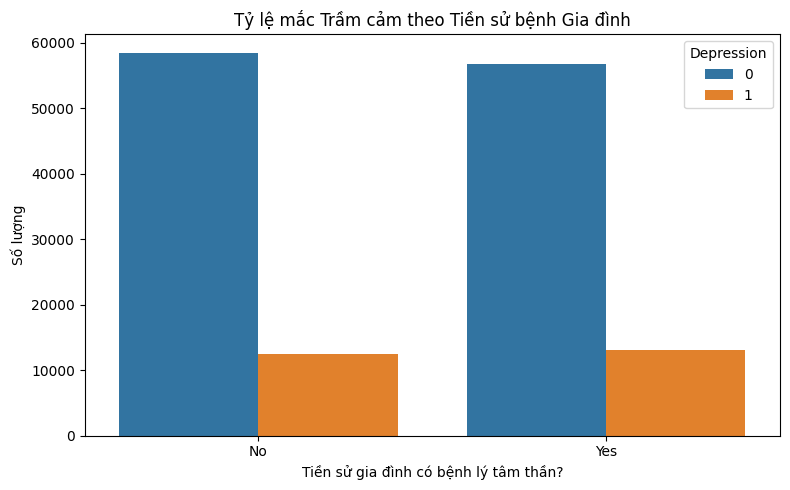

✅ Đã lưu: images/family_history_analysis.png


<Figure size 640x480 with 0 Axes>

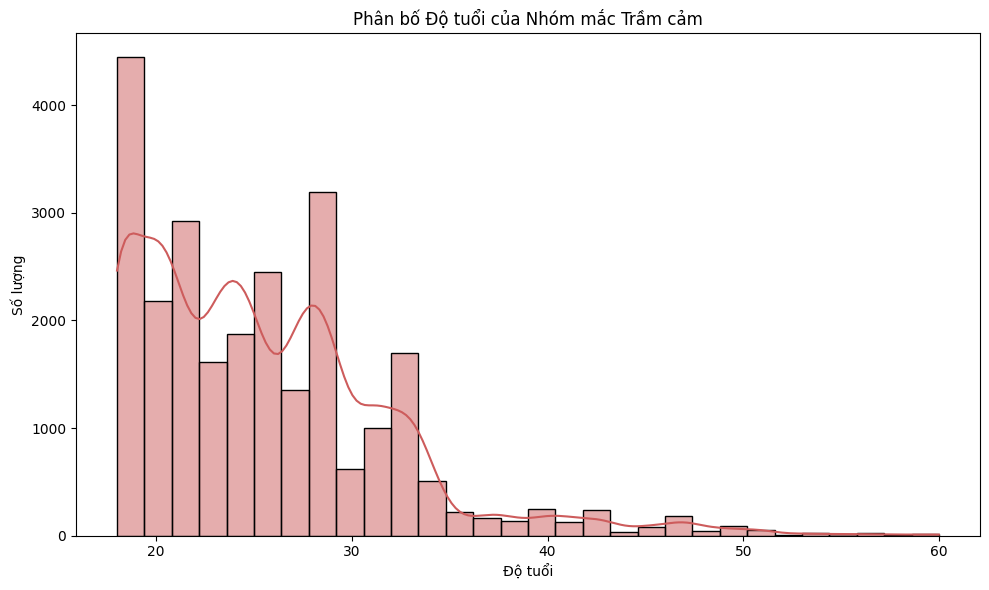

✅ Đã lưu: images/age_distribution_depression.png


<Figure size 640x480 with 0 Axes>

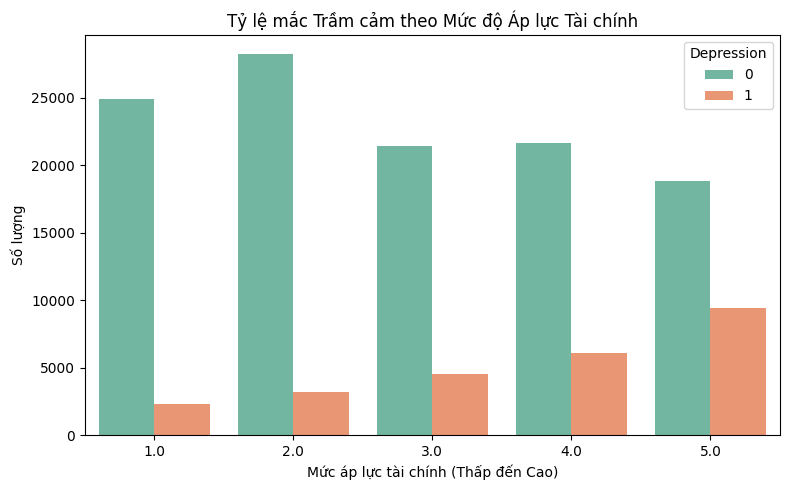

✅ Đã lưu: images/financial_stress_analysis.png


<Figure size 640x480 with 0 Axes>

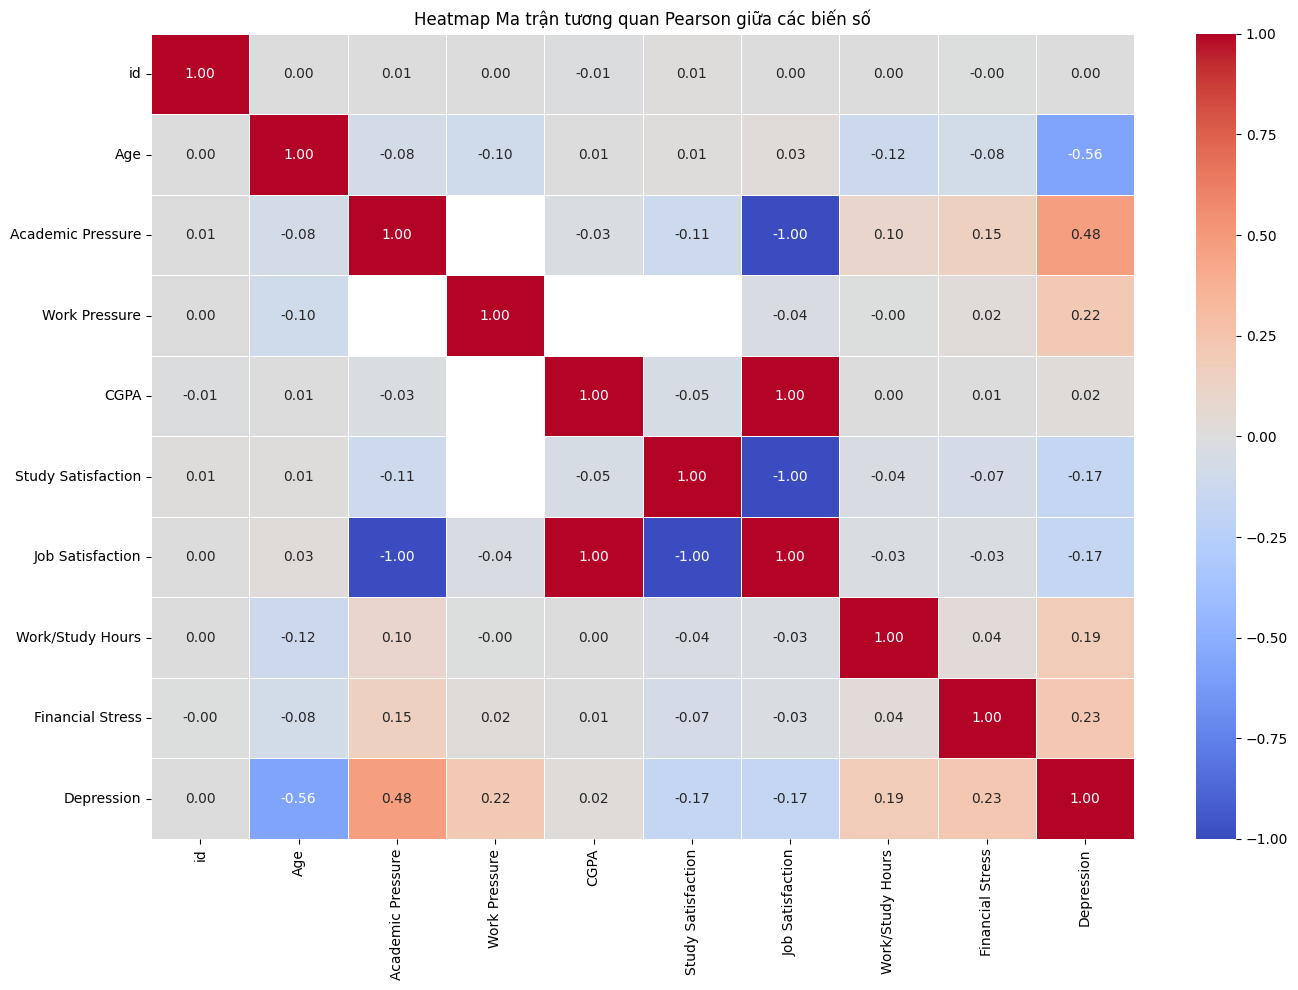

✅ Đã lưu: images/correlation_heatmap.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# # Import bổ sung thư viện quản lý thư mục
# import os

# # TASK: Xuất và lưu tất cả biểu đồ
# output_dir = 'plots'
# os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# TASK: Liên hệ giữa Suy nghĩ tự tử và Tỷ lệ trầm cảm
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='Have you ever had suicidal thoughts ?', hue='Depression')
plt.title('Tỷ lệ mắc Trầm cảm theo Tiền sử Suy nghĩ tự tử')
plt.xlabel('Từng có suy nghĩ tự tử?')
plt.ylabel('Số lượng')
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'suicidal_thoughts_vs_depression.png'))
plt.show()
export_plot("suicidal_thoughts_analysis")

# ---------------------------------------------------------
# TASK: Liên hệ giữa Tiền sử bệnh gia đình và Tỷ lệ trầm cảm
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='Family History of Mental Illness', hue='Depression')
plt.title('Tỷ lệ mắc Trầm cảm theo Tiền sử bệnh Gia đình')
plt.xlabel('Tiền sử gia đình có bệnh lý tâm thần?')
plt.ylabel('Số lượng')
plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'family_history_vs_depression.png'))
plt.show()
export_plot("family_history_analysis")

# ---------------------------------------------------------
# TASK: Biểu đồ phân bố độ tuổi của nhóm bị trầm cảm
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Lọc mảng dữ liệu chỉ chứa những người bị Trầm cảm (Depression == 1)
depression_only = df_train[df_train['Depression'] == 1]

# Dùng kde=True để hiển thị đường cong phân bố, bins để chia nhóm cột tuổi
sns.histplot(data=depression_only, x='Age', kde=True, bins=30, color='indianred')
plt.title('Phân bố Độ tuổi của Nhóm mắc Trầm cảm')
plt.xlabel('Độ tuổi')
plt.ylabel('Số lượng')
plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'age_distribution_depression.png'))
plt.show()
export_plot("age_distribution_depression")

# ---------------------------------------------------------
# TASK: Áp lực tài chính và Tỷ lệ trầm cảm
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='Financial Stress', hue='Depression', palette='Set2')
plt.title('Tỷ lệ mắc Trầm cảm theo Mức độ Áp lực Tài chính')
plt.xlabel('Mức áp lực tài chính (Thấp đến Cao)')
plt.ylabel('Số lượng')
plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'financial_stress_vs_depression.png'))
plt.show()
export_plot("financial_stress_analysis")

# ---------------------------------------------------------
# TASK: Ma trận tương quan Pearson & Vẽ Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))

# Lọc bỏ các cột chứa chữ (String/Object), chỉ giữ lại các cột số (numeric) để tính Correlation
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
pearson_corr = df_train[numeric_cols].corr(method='pearson')

# Vẽ Heatmap
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Ma trận tương quan Pearson giữa các biến số')
plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'pearson_correlation_heatmap.png'))
plt.show()
export_plot("correlation_heatmap")